Manual norm: 0.06634383375684128


/Users/wilhelmfaerden/miniforge3/envs/fenicsx-env/lib/python3.11/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


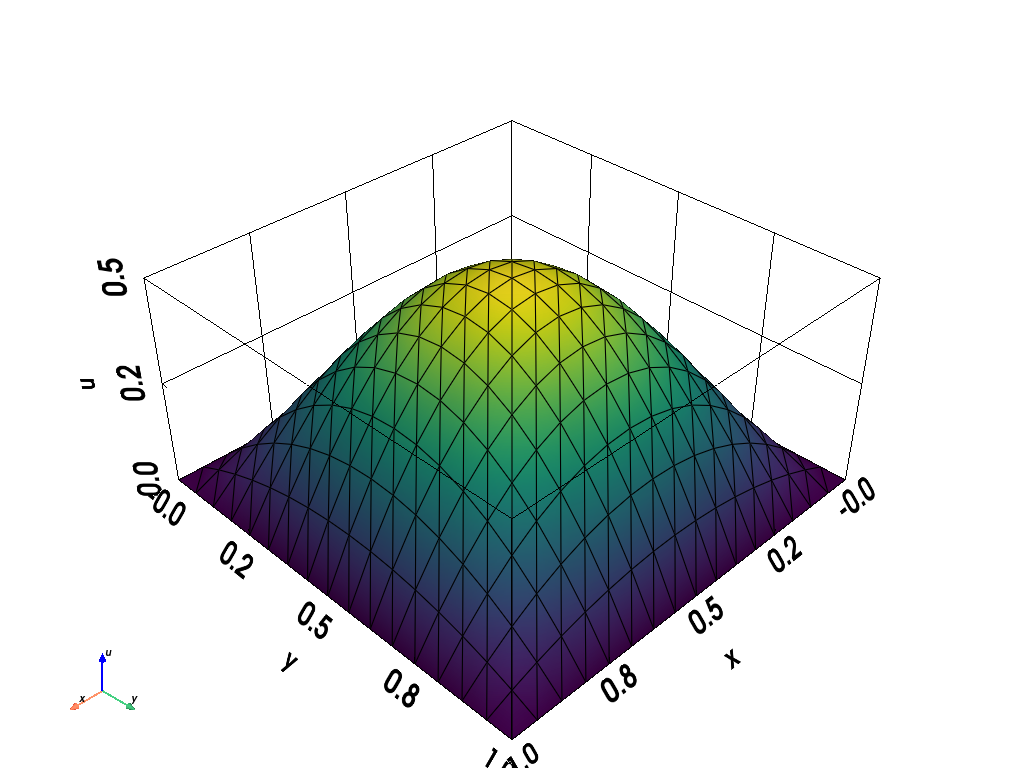

In [ ]:
# TO DO:
# Loop for different mesh grids resolutions (or just manually)
# 3D plot
# Convergence test
# Crouzeix-Raviart?
# Part II: add Neumann bcs, zero mean condition


# Fix MPI/OFI finalization errors on macOS
import os

os.environ["FI_PROVIDER"] = "tcp"
os.environ["MPICH_OFI_STARTUP_CONNECT"] = "0"


from mpi4py import MPI
import numpy as np
import matplotlib.pyplot as plt
from petsc4py.PETSc import ScalarType
from dolfinx import mesh, fem, plot, io, la
from dolfinx.fem.petsc import LinearProblem
import ufl
import pyvista
from scipy.sparse import csr_matrix


# Mesh
msh = mesh.create_rectangle(
    comm=MPI.COMM_WORLD,
    points=((0.0, 0.0), (1.0, 1.0)),
    n=(16, 16),
    cell_type=mesh.CellType.triangle,
)

# Function space
V = fem.functionspace(msh, ("CG", 1))
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)


# Dicichlet boundary conditions
def marker(x):
    return (
        np.isclose(x[0], 0.0)
        | np.isclose(x[1], 0.0)
        | np.isclose(x[0], 1.0)
        | np.isclose(x[1], 1.0)
    )

facets = mesh.locate_entities_boundary(msh, dim=(msh.topology.dim - 1), marker=marker)
dofs = fem.locate_dofs_topological(V=V, entity_dim=1, entities=facets)
bc = fem.dirichletbc(value=ScalarType(0), dofs=dofs, V=V)


# RHS function
x = ufl.SpatialCoordinate(msh)
f = 2.0 * (x[0] * (1.0 - x[0]) + x[1] * (1.0 - x[1]))
D = 1
u_exact = -x[0] * x[1] * (1.0 - x[0]) * (1.0 - x[1]) # known test solution (giving our corr. f)


# Variational form
a = ufl.inner(D*ufl.grad(u), ufl.grad(v)) * ufl.dx # stiffness matrix
L = ufl.inner(f, v) * ufl.dx # load vector

A = fem.assemble_matrix(fem.form(a))
b = fem.assemble_vector(fem.form(L))
#print(A.to_dense())
#print(b.array)

# Problem
problem = LinearProblem(
    a,
    L,
    bcs=[bc],
    petsc_options_prefix="test_poisson_",
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu",
        "ksp_error_if_not_converged": True,
    },
)

uh = problem.solve()


l2_error = np.sqrt(
    fem.assemble_scalar(fem.form(ufl.inner(uh - u_exact, uh - u_exact) * ufl.dx))
)


print(f"Manual norm: {l2_error}")



###############################
# Plotting with pyvista (3D)
###############################
cells, types, x = plot.vtk_mesh(V)
grid = pyvista.UnstructuredGrid(cells, types, x)
grid.point_data["u"] = uh.x.array.real
grid.set_active_scalars("u")

warp_factor = 8
warped = grid.warp_by_scalar("u", factor=warp_factor)

plotter = pyvista.Plotter()
plotter.add_mesh(
    warped,
    scalars="u",
    cmap="viridis",
    show_scalar_bar=False,
    show_edges=True,
    edge_color="black",
    line_width=0.6,
    smooth_shading=True,
    lighting=True,
)
plotter.show_bounds(grid="back", location="outer", all_edges=True, xtitle="x", ytitle="y", ztitle="u", font_size=25, n_zlabels=3)
plotter.add_axes(xlabel="x", ylabel="y", zlabel="u")
plotter.view_isometric()
plotter.show()


with io.XDMFFile(msh.comm, "output/poisson.xdmf", "w") as file:
    file.write_mesh(msh)
    file.write_function(uh)
